# Predição de Níveis de Obesidade com Machine Learning
**Tech Challenge Fase 4 | FIAP | Pós-Tech Data Analytics**

Este notebook documenta o pipeline completo de análise exploratória, preparação dos dados e modelagem preditiva para classificação de níveis de obesidade com base em dados demográficos, hábitos alimentares e de atividade física.

**Dataset:** Obesity.csv | 2.111 registros | 17 variáveis | 7 classes

---

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
print("Caminho do Google Drive conectado:")
print(os.listdir('/content/drive/My Drive'))

Caminho do Google Drive conectado:
['foto 1.jpg', 'foto rg.jpg', 'discurso form.pdf', 'Edu Explica 2GM: Triângulos do Holocausto', 'conclusão inglês.jpg', 'foto LinkedIn', 'Contrato Estágio - CBA.pdf', 'CV Caroline B Alencar.pdf', 'Planejamento Financeiro.xlsx', 'Vídeo natal unasp Bianca Molina e CBA.mp4', 'Salvo do Chrome', 'discurso 2 form.docx', 'DOC_LOGAN_BYP9F69.pdf', 'Controle_Financeiro.xlsx', 'diploma_unifesp.pdf', 'CNH-e_Caroline.pdf.pdf', 'RG_Caroline.pdf', 'Colab Notebooks', 'vídeo festa bp 2024.mp4', '06-02-2026 08.17.m4a', 'Certidao_nascimento.pdf', 'Foto_202602', 'U178O1L44598.PDF', 'bq-results-20260329-230951-1774825820349', 'bq-results-20260330-031923-1774840829419', 'bq-results-20260403-024841-1775184610584', 'SQL_TechChallenge3.txt', 'Obesity.csv', 'data', 'Cópia de TC4_Obesity_CORRIGIDO_Fases1-2 (1).ipynb', 'Cópia de TC4_Obesity_CORRIGIDO_Fases1-2.ipynb', 'metadata.json', 'X_train.pkl', 'best_model.pkl', 'Obesity_processed.csv', 'X_test.csv', 'y_test.csv', 'X

In [3]:
#new
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
import joblib
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

print("✅ Imports corretos carregados!")

✅ Imports corretos carregados!


In [4]:
import pandas as pd

df = pd.read_csv('/content/drive/My Drive/Obesity.csv')
print("✅ Arquivo carregado!")
print(df.head())

✅ Arquivo carregado!
   Gender   Age  Height  Weight family_history FAVC  FCVC  NCP       CAEC  \
0  Female  21.0    1.62    64.0            yes   no   2.0  3.0  Sometimes   
1  Female  21.0    1.52    56.0            yes   no   3.0  3.0  Sometimes   
2    Male  23.0    1.80    77.0            yes   no   2.0  3.0  Sometimes   
3    Male  27.0    1.80    87.0             no   no   3.0  3.0  Sometimes   
4    Male  22.0    1.78    89.8             no   no   2.0  1.0  Sometimes   

  SMOKE  CH2O  SCC  FAF  TUE        CALC                 MTRANS  \
0    no   2.0   no  0.0  1.0          no  Public_Transportation   
1   yes   3.0  yes  3.0  0.0   Sometimes  Public_Transportation   
2    no   2.0   no  2.0  1.0  Frequently  Public_Transportation   
3    no   2.0   no  2.0  0.0  Frequently                Walking   
4    no   2.0   no  0.0  0.0   Sometimes  Public_Transportation   

               Obesity  
0        Normal_Weight  
1        Normal_Weight  
2        Normal_Weight  
3   Overweigh

## Fase 1: Exploração e Análise Descritiva dos Dados

Objetivo desta etapa é entender a estrutura do dataset, verificar qualidade dos dados e identificar padrões relevantes antes de qualquer transformação.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

PALETTE = {
    'Insufficient_Weight': '#3B82F6',
    'Normal_Weight':       '#22C55E',
    'Overweight_Level_I':  '#F59E0B',
    'Overweight_Level_II': '#F97316',
    'Obesity_Type_I':      '#EF4444',
    'Obesity_Type_II':     '#B91C1C',
    'Obesity_Type_III':    '#7F1D1D',
}
ORDER  = list(PALETTE.keys())
COLORS = list(PALETTE.values())

BG, CARD, TEXT = '#0F1117', '#1A1D27', '#E5E7EB'
plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': CARD,
    'axes.labelcolor': TEXT, 'xtick.color': TEXT, 'ytick.color': TEXT,
    'text.color': TEXT, 'grid.color': '#2D3148', 'grid.linewidth': 0.5,
})

### Carregamento dos dados

In [6]:
df = pd.read_csv('/content/drive/My Drive/Obesity.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (2111, 17)


,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


### Tipos de dados e valores ausentes

In [7]:
print('Tipos de dados:')
print(df.dtypes)

print(f'\nValores ausentes por coluna:')
print(df.isnull().sum())

Tipos de dados:
Gender             object
Age               float64
Height            float64
Weight            float64
family_history     object
FAVC               object
FCVC              float64
NCP               float64
CAEC               object
SMOKE              object
CH2O              float64
SCC                object
FAF               float64
TUE               float64
CALC               object
MTRANS             object
Obesity            object
dtype: object

Valores ausentes por coluna:
Gender            0
Age               0
Height            0
Weight            0
family_history    0
FAVC              0
FCVC              0
NCP               0
CAEC              0
SMOKE             0
CH2O              0
SCC               0
FAF               0
TUE               0
CALC              0
MTRANS            0
Obesity           0
dtype: int64


### Estatísticas descritivas

In [8]:
df.describe().round(3)

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000,2111.000,2111.000,2111.000,2111.000,2111.000,2111.000,2111.000
mean,24.313,1.702,86.586,2.419,2.686,2.008,1.010,0.658
std,6.346,0.093,26.191,0.534,0.778,0.613,0.851,0.609
min,14.000,1.450,39.000,1.000,1.000,1.000,0.000,0.000
25%,19.947,1.630,65.473,2.000,2.659,1.585,0.125,0.000
50%,22.778,1.700,83.000,2.386,3.000,2.000,1.000,0.625
75%,26.000,1.768,107.431,3.000,3.000,2.477,1.667,1.000
max,61.000,1.980,173.000,3.000,4.000,3.000,3.000,2.000


### Distribuição da variável alvo

As classes estão relativamente equilibradas, com variação entre 12,9% e 16,6%. Não será necessário aplicar técnicas de balanceamento como SMOTE.

In [9]:
counts = df['Obesity'].value_counts().reindex(ORDER)
for cls, cnt in counts.items():
    pct = cnt / len(df) * 100
    print(f'{cls:<25} {cnt:>4}  ({pct:.1f}%)')

print(f'\nRazao max/min: {counts.max()/counts.min():.2f}x')

Insufficient_Weight        272  (12.9%)
Normal_Weight              287  (13.6%)
Overweight_Level_I         290  (13.7%)
Overweight_Level_II        290  (13.7%)
Obesity_Type_I             351  (16.6%)
Obesity_Type_II            297  (14.1%)
Obesity_Type_III           324  (15.3%)

Razao max/min: 1.29x


### Criação do IMC

O IMC (Índice de Massa Corporal) não está presente no dataset original, mas pode ser derivado diretamente de Peso e Altura. É a métrica clínica central para classificação de obesidade.

In [10]:
df['BMI'] = (df['Weight'] / df['Height'] ** 2).round(2)

bmi_stats = df.groupby('Obesity')['BMI'].agg(['mean','std','min','max']).reindex(ORDER).round(2)
print(bmi_stats)

                      mean   std    min    max
Obesity                                       
Insufficient_Weight  17.40  0.79  13.00  19.08
Normal_Weight        22.01  1.84  18.49  24.91
Overweight_Level_I   25.99  0.66  22.83  28.77
Overweight_Level_II  28.22  0.83  25.71  30.36
Obesity_Type_I       32.26  1.13  29.91  35.17
Obesity_Type_II      36.72  1.29  34.05  39.79
Obesity_Type_III     42.27  2.58  36.77  50.81


### Detecção de outliers via IQR

In [11]:
for col in ['Age', 'Height', 'Weight', 'BMI']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f'{col:<10}: {n_out} outliers')

Age       : 168 outliers
Height    : 1 outliers
Weight    : 1 outliers
BMI       : 0 outliers


### Análise das variáveis categóricas

Verificação das distribuições para identificar categorias dominantes e possíveis desbalanceamentos.

In [12]:
for col in df.select_dtypes('object').columns.drop('Obesity'):
    print(f'\n{col}:')
    print(df[col].value_counts().to_string())


Gender:
Gender
Male      1068
Female    1043

family_history:
family_history
yes    1726
no      385

FAVC:
FAVC
yes    1866
no      245

CAEC:
CAEC
Sometimes     1765
Frequently     242
Always          53
no              51

SMOKE:
SMOKE
no     2067
yes      44

SCC:
SCC
no     2015
yes      96

CALC:
CALC
Sometimes     1401
no             639
Frequently      70
Always           1

MTRANS:
MTRANS
Public_Transportation    1580
Automobile                457
Walking                    56
Motorbike                  11
Bike                        7


---
### Visualizações exploratórias

**Distribuição das classes de obesidade**

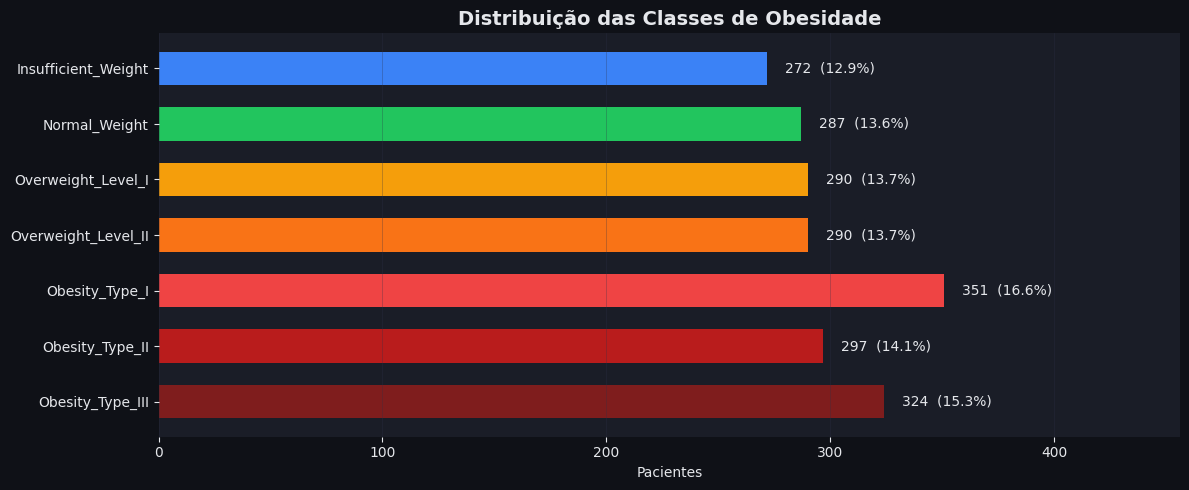

In [13]:
fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
counts = df['Obesity'].value_counts().reindex(ORDER)
bars = ax.barh(ORDER[::-1], counts.values[::-1], color=COLORS[::-1], edgecolor='none', height=0.6)
for bar, val in zip(bars, counts.values[::-1]):
    pct = val / len(df) * 100
    ax.text(bar.get_width() + 8, bar.get_y() + bar.get_height()/2,
            f'{val}  ({pct:.1f}%)', va='center', fontsize=10, color=TEXT)
ax.set_xlim(0, counts.max() * 1.3)
ax.set_title('Distribuição das Classes de Obesidade', fontsize=14, fontweight='bold', color=TEXT)
ax.set_xlabel('Pacientes')
ax.grid(axis='x', alpha=0.4)
ax.spines[:].set_visible(False)
plt.tight_layout()
plt.savefig('viz1_distribuicao.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

**IMC por nível de obesidade**

O box plot confirma que o IMC separa as classes de forma clara e progressiva, o que indica alto poder discriminativo dessa feature para o modelo.

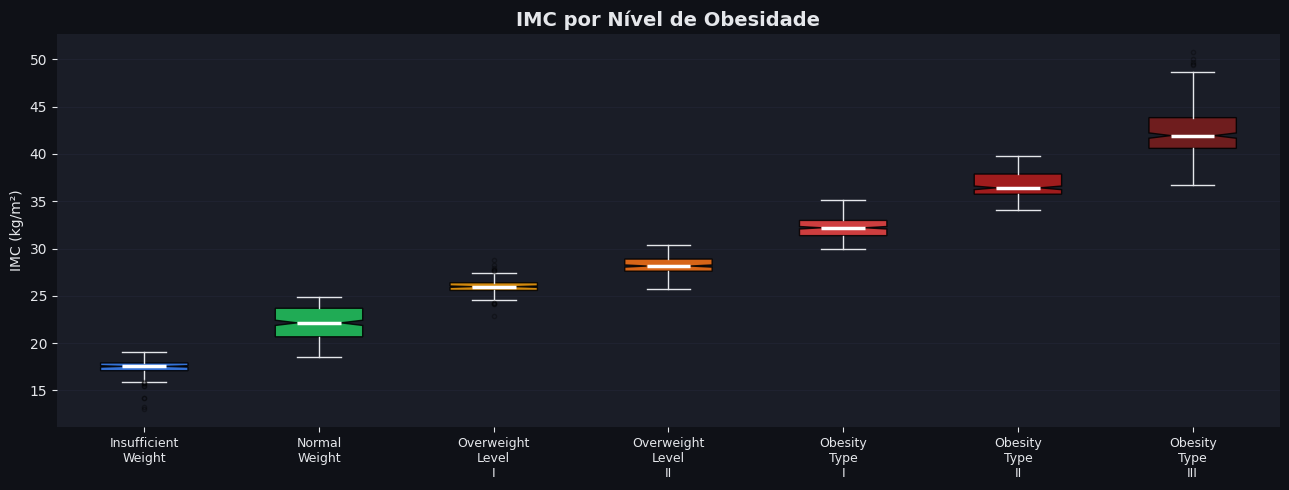

In [14]:
fig, ax = plt.subplots(figsize=(13, 5), facecolor=BG)
data_by_class = [df[df['Obesity'] == cls]['BMI'].values for cls in ORDER]
bp = ax.boxplot(data_by_class, patch_artist=True, notch=True,
                medianprops=dict(color='white', linewidth=2.5),
                whiskerprops=dict(color=TEXT), capprops=dict(color=TEXT),
                flierprops=dict(marker='o', color=TEXT, alpha=0.3, markersize=3))
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.85)
ax.set_xticks(range(1, 8))
ax.set_xticklabels([o.replace('_', '\n') for o in ORDER], fontsize=9)
ax.set_title('IMC por Nível de Obesidade', fontsize=14, fontweight='bold', color=TEXT)
ax.set_ylabel('IMC (kg/m²)')
ax.grid(axis='y', alpha=0.4); ax.spines[:].set_visible(False)
plt.tight_layout()
plt.savefig('viz2_imc_boxplot.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

**Distribuição por gênero em cada nível**

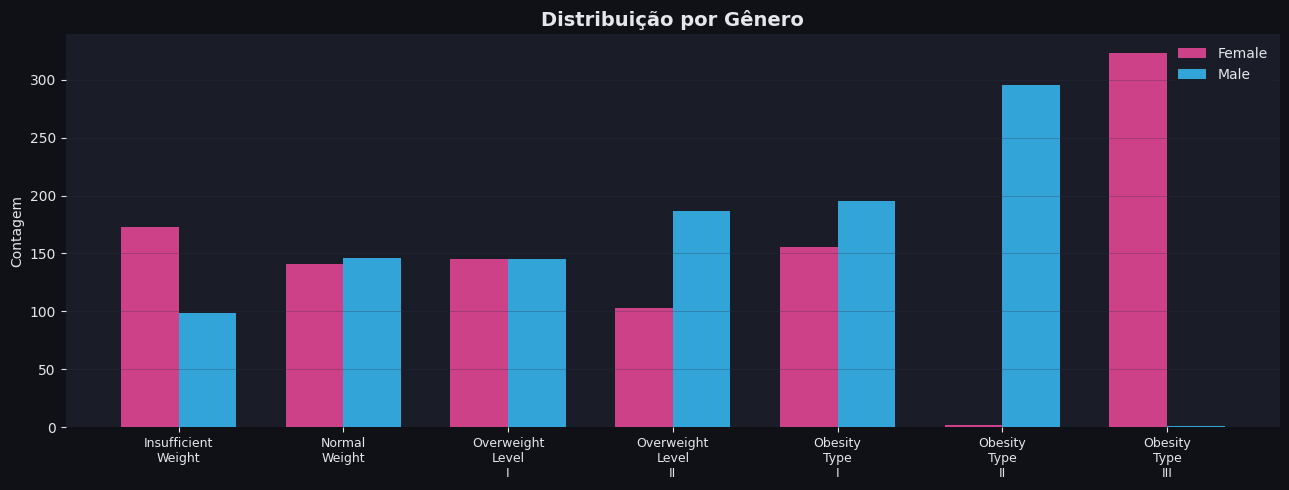

In [15]:
fig, ax = plt.subplots(figsize=(13, 5), facecolor=BG)
ct = pd.crosstab(df['Obesity'], df['Gender']).reindex(ORDER)
x = np.arange(len(ORDER)); w = 0.35
ax.bar(x - w/2, ct['Female'], width=w, label='Female', color='#EC4899', alpha=0.85, edgecolor='none')
ax.bar(x + w/2, ct['Male'],   width=w, label='Male',   color='#38BDF8', alpha=0.85, edgecolor='none')
ax.set_xticks(x)
ax.set_xticklabels([o.replace('_', '\n') for o in ORDER], fontsize=9)
ax.set_title('Distribuição por Gênero', fontsize=14, fontweight='bold', color=TEXT)
ax.set_ylabel('Contagem')
ax.legend(facecolor=CARD, labelcolor=TEXT, edgecolor='none')
ax.grid(axis='y', alpha=0.4); ax.spines[:].set_visible(False)
plt.tight_layout()
plt.savefig('viz3_genero_classe.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

**Atividade física e histórico familiar**

Observa-se que pacientes com maior obesidade tendem a praticar menos atividade física e possuem histórico familiar mais presente, o que reforça o peso dessas variáveis na predição.

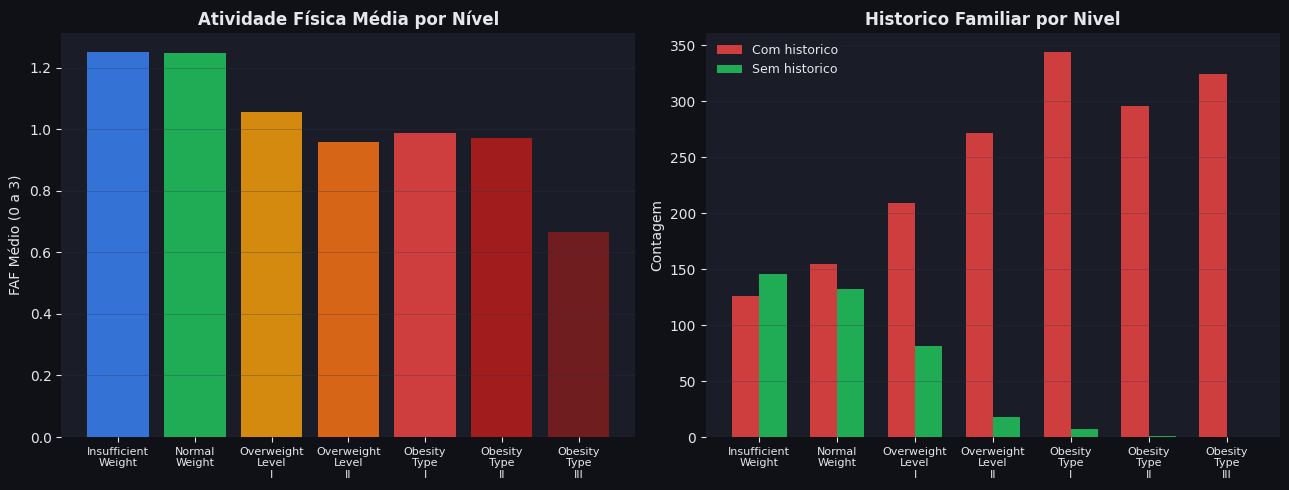

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=BG)

ax = axes[0]
means_faf = df.groupby('Obesity')['FAF'].mean().reindex(ORDER)
ax.bar(range(len(ORDER)), means_faf, color=[PALETTE[o] for o in ORDER], edgecolor='none', alpha=0.85)
ax.set_xticks(range(len(ORDER)))
ax.set_xticklabels([o.replace('_', '\n') for o in ORDER], fontsize=8)
ax.set_title('Atividade Física Média por Nível', fontsize=12, fontweight='bold', color=TEXT)
ax.set_ylabel('FAF Médio (0 a 3)')
ax.grid(axis='y', alpha=0.4); ax.spines[:].set_visible(False)

ax = axes[1]
fh = df.groupby(['Obesity','family_history']).size().unstack(fill_value=0).reindex(ORDER)
x = np.arange(len(ORDER)); w = 0.35
ax.bar(x - w/2, fh.get('yes', 0), width=w, label='Com historico', color='#EF4444', alpha=0.85, edgecolor='none')
ax.bar(x + w/2, fh.get('no', 0),  width=w, label='Sem historico', color='#22C55E', alpha=0.85, edgecolor='none')
ax.set_xticks(x); ax.set_xticklabels([o.replace('_', '\n') for o in ORDER], fontsize=8)
ax.set_title('Historico Familiar por Nivel', fontsize=12, fontweight='bold', color=TEXT)
ax.set_ylabel('Contagem')
ax.legend(facecolor=CARD, labelcolor=TEXT, edgecolor='none', fontsize=9)
ax.grid(axis='y', alpha=0.4); ax.spines[:].set_visible(False)

plt.tight_layout()
plt.savefig('viz4_faf_familia.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

**Mapa de correlação entre variáveis**

BMI e Weight apresentam as correlações mais altas com a variável alvo, confirmando a relevância dessas features para o modelo.

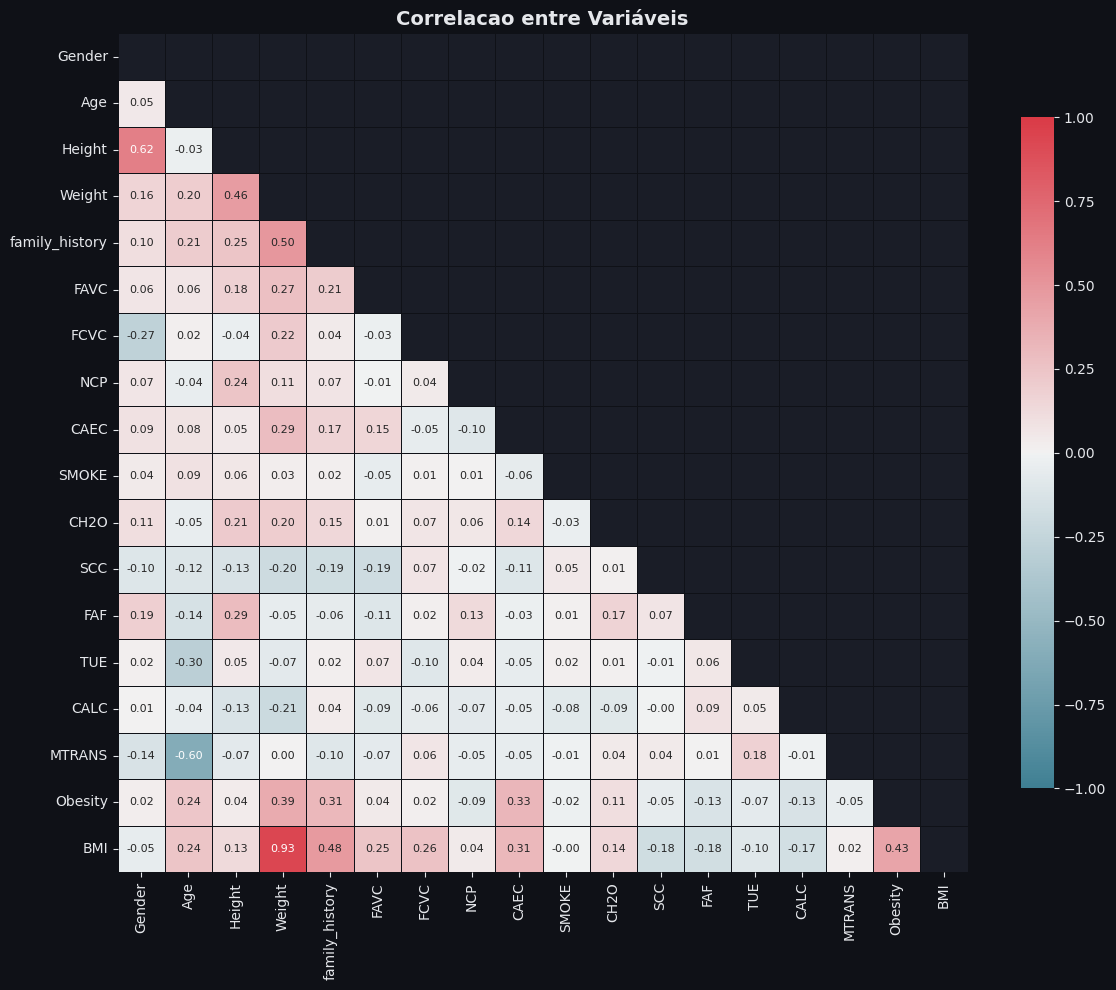

In [17]:
df_corr = df.copy()
for col in df_corr.select_dtypes('object').columns:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col])

corr = df_corr.corr()
fig, ax = plt.subplots(figsize=(12, 10), facecolor=BG)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap=sns.diverging_palette(220, 10, as_cmap=True),
            center=0, vmax=1, vmin=-1, annot=True, fmt='.2f',
            annot_kws={'size': 8}, linewidths=0.5, linecolor=BG,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlacao entre Variáveis', fontsize=14, fontweight='bold', color=TEXT)
plt.tight_layout()
plt.savefig('viz5_correlacao.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

---
## Fase 2: Feature Engineering e Preparação para Modelagem

Transformações necessárias para que os algoritmos de Machine Learning processem os dados corretamente.

### Arredondamento de variáveis escalonadas

Conforme o dicionário de dados, as variáveis FCVC, NCP, CH2O, FAF e TUE representam escalas inteiras, mas foram coletadas com casas decimais. O arredondamento recupera a interpretação original de cada categoria.

In [18]:
df = pd.read_csv('/content/drive/My Drive/Obesity.csv')
df['BMI'] = (df['Weight'] / df['Height'] ** 2).round(2)

SCALE_COLS = ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
for col in SCALE_COLS:
    df[col] = df[col].round().astype(int)

print('Distribuicao apos arredondamento:')
for col in SCALE_COLS:
    print(f'  {col}: {sorted(df[col].unique())}')

Distribuicao apos arredondamento:
  FCVC: [np.int64(1), np.int64(2), np.int64(3)]
  NCP: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  CH2O: [np.int64(1), np.int64(2), np.int64(3)]
  FAF: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  TUE: [np.int64(0), np.int64(1), np.int64(2)]


### Codificação da variável alvo

Encoding ordinal respeitando a ordem clínica de gravidade, de Insufficient_Weight (0) a Obesity_Type_III (6).

In [19]:
TARGET_ORDER = [
    'Insufficient_Weight', 'Normal_Weight',
    'Overweight_Level_I', 'Overweight_Level_II',
    'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III'
]
target_map = {cls: i for i, cls in enumerate(TARGET_ORDER)}
y = df['Obesity'].map(target_map)

print('Mapeamento aplicado:')
for cls, num in target_map.items():
    print(f'  {num} -> {cls}')

Mapeamento aplicado:
  0 -> Insufficient_Weight
  1 -> Normal_Weight
  2 -> Overweight_Level_I
  3 -> Overweight_Level_II
  4 -> Obesity_Type_I
  5 -> Obesity_Type_II
  6 -> Obesity_Type_III


### Encoding das variáveis categóricas

Estratégia definida por tipo de variável:
- Binárias (yes/no): mapeamento direto para 0/1
- Ordinais (CAEC, CALC): encoding ordinal preservando a ordem de frequência
- Nominais (MTRANS): one-hot encoding, pois não existe hierarquia entre os meios de transporte

In [20]:
X = df.drop(columns=['Obesity'])

BINARY_COLS = ['family_history', 'FAVC', 'SMOKE', 'SCC']
for col in BINARY_COLS:
    X[col] = (X[col] == 'yes').astype(int)

X['Gender'] = (X['Gender'] == 'Male').astype(int)

FREQ_ORDER = ['no', 'Sometimes', 'Frequently', 'Always']
for col in ['CAEC', 'CALC']:
    oe = OrdinalEncoder(categories=[FREQ_ORDER])
    X[col] = oe.fit_transform(X[[col]]).astype(int)

MTRANS_DUMMIES = pd.get_dummies(X['MTRANS'], prefix='MTRANS', drop_first=False)
X = pd.concat([X.drop(columns='MTRANS'), MTRANS_DUMMIES], axis=1)
ohe_cols = [c for c in X.columns if c.startswith('MTRANS_')]
X[ohe_cols] = X[ohe_cols].astype(int)

print(f'Shape final de X: {X.shape}')
print(f'Colunas: {list(X.columns)}')

Shape final de X: (2111, 21)
Colunas: ['Gender', 'Age', 'Height', 'Weight', 'family_history', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'BMI', 'MTRANS_Automobile', 'MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation', 'MTRANS_Walking']


### Divisão treino e teste

Divisão estratificada 80/20 para preservar as proporções de cada classe nos dois conjuntos. O parâmetro `random_state` garante reprodutibilidade.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treino : {X_train.shape[0]} amostras')
print(f'Teste  : {X_test.shape[0]} amostras')

print('\nDistribuicao por classe (treino vs teste):')
train_pct = y_train.value_counts(normalize=True).sort_index() * 100
test_pct  = y_test.value_counts(normalize=True).sort_index() * 100
for i, cls in enumerate(TARGET_ORDER):
    print(f'  {cls:<25} treino {train_pct[i]:.1f}%  |  teste {test_pct[i]:.1f}%')

Treino : 1688 amostras
Teste  : 423 amostras

Distribuicao por classe (treino vs teste):
  Insufficient_Weight       treino 12.9%  |  teste 12.8%
  Normal_Weight             treino 13.6%  |  teste 13.7%
  Overweight_Level_I        treino 13.7%  |  teste 13.7%
  Overweight_Level_II       treino 13.7%  |  teste 13.7%
  Obesity_Type_I            treino 16.6%  |  teste 16.5%
  Obesity_Type_II           treino 14.0%  |  teste 14.2%
  Obesity_Type_III          treino 15.3%  |  teste 15.4%


### Normalização

StandardScaler aplicado apenas nas variáveis contínuas (Age, Height, Weight, BMI). O scaler é ajustado exclusivamente nos dados de treino e aplicado ao teste, evitando vazamento de informação.

In [22]:
SCALE_FEATURES = ['Age', 'Height', 'Weight', 'BMI']
scaler = StandardScaler()

X_train[SCALE_FEATURES] = scaler.fit_transform(X_train[SCALE_FEATURES])
X_test[SCALE_FEATURES]  = scaler.transform(X_test[SCALE_FEATURES])

print('Estatisticas apos normalizacao (treino):')
print(X_train[SCALE_FEATURES].describe().round(3))

Estatisticas apos normalizacao (treino):
            Age    Height    Weight       BMI
count  1688.000  1688.000  1688.000  1688.000
mean      0.000    -0.000    -0.000    -0.000
std       1.000     1.000     1.000     1.000
min      -1.475    -2.693    -1.819    -2.089
25%      -0.692    -0.771    -0.781    -0.669
50%      -0.240     0.000    -0.143    -0.120
75%       0.268     0.706     0.796     0.784
max       5.812     3.016     3.028     2.649


### Feature importance

Random Forest treinado para avaliar a relevância de cada variável. Resultado esperado: BMI e Weight no topo, dado que o IMC é justamente o critério clínico de classificação de obesidade.

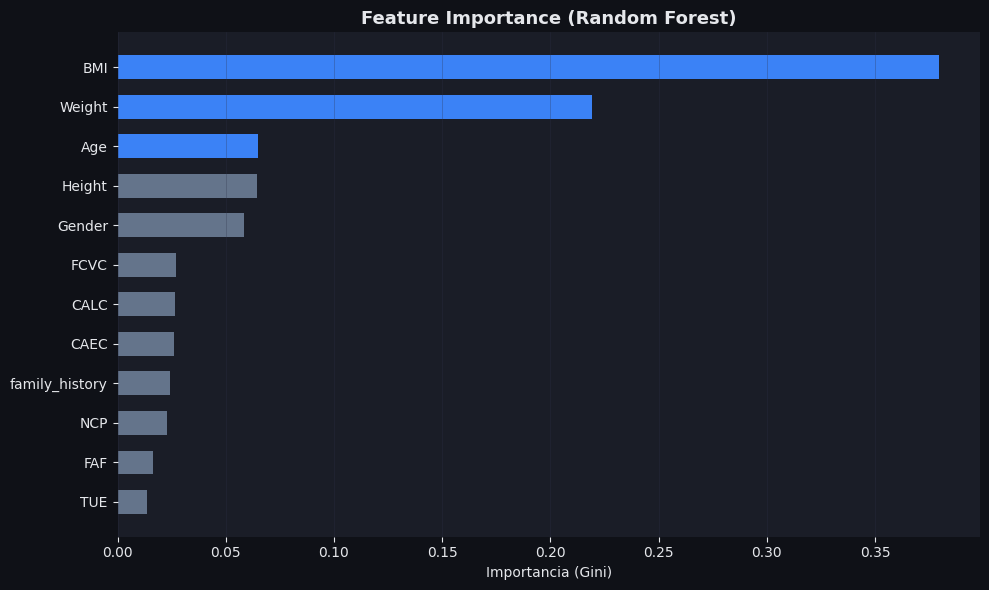

Top 5 features:
  BMI                            0.3796
  Weight                         0.2194
  Age                            0.0647
  Height                         0.0645
  Gender                         0.0584


In [23]:
rf_fi = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_fi.fit(X_train, y_train)

importances = pd.Series(rf_fi.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
top_n = importances.head(12)
colors = ['#3B82F6' if i < 3 else '#64748B' for i in range(len(top_n))]
ax.barh(top_n.index[::-1], top_n.values[::-1], color=colors[::-1], edgecolor='none', height=0.6)
ax.set_title('Feature Importance (Random Forest)', fontsize=13, fontweight='bold', color=TEXT)
ax.set_xlabel('Importancia (Gini)')
ax.grid(axis='x', alpha=0.4); ax.spines[:].set_visible(False)
plt.tight_layout()
plt.savefig('viz6_feature_importance.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

print('Top 5 features:')
for feat, val in importances.head(5).items():
    print(f'  {feat:<30} {val:.4f}')

### Exportação dos dados processados

In [24]:
import json, os

os.makedirs('/content/drive/MyDrive/TC4_Obesity', exist_ok=True)

X_train.to_csv('/content/drive/MyDrive/TC4_Obesity/X_train.csv', index=False)
X_test.to_csv('/content/drive/MyDrive/TC4_Obesity/X_test.csv',   index=False)
y_train.to_csv('/content/drive/MyDrive/TC4_Obesity/y_train.csv', index=False)
y_test.to_csv('/content/drive/MyDrive/TC4_Obesity/y_test.csv',   index=False)

meta = {
    'feature_names': list(X_train.columns),
    'target_classes': TARGET_ORDER,
    'binary_cols': BINARY_COLS + ['Gender'],
    'scale_cols': SCALE_COLS,
    'ohe_cols': [c for c in X_train.columns if c.startswith('MTRANS_')],
    'ordinal_cols': ['CAEC', 'CALC'],
    'numeric_scaled': SCALE_FEATURES,
    'scaler_mean': scaler.mean_.tolist(),
    'scaler_std': scaler.scale_.tolist(),
    'freq_order': ['no', 'Sometimes', 'Frequently', 'Always'],
    'mtrans_categories': [c.replace('MTRANS_', '') for c in X_train.columns if c.startswith('MTRANS_')]
}
with open('/content/drive/MyDrive/TC4_Obesity/feature_metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

import pickle
with open('/content/drive/MyDrive/TC4_Obesity/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('Arquivos salvos em /TC4_Obesity/ no Google Drive:')
print('  X_train.csv, X_test.csv, y_train.csv, y_test.csv')
print('  feature_metadata.json, scaler.pkl')

Arquivos salvos em /TC4_Obesity/ no Google Drive:
  X_train.csv, X_test.csv, y_train.csv, y_test.csv
  feature_metadata.json, scaler.pkl


---
## Fase 3: Treinamento, Validação e Seleção do Modelo

Três algoritmos são avaliados com validação cruzada estratificada. O critério de seleção é o F1-Score macro, mais adequado para classificação multiclasse. O modelo com melhor desempenho passa por otimização de hiperparâmetros antes da exportação final.

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)
import pickle
import time

TARGET_ORDER = [
    'Insufficient_Weight', 'Normal_Weight',
    'Overweight_Level_I', 'Overweight_Level_II',
    'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III'
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']
print('Imports carregados.')

Imports carregados.


### Validação cruzada — comparação entre modelos

Cada modelo é avaliado com 5-fold stratified cross-validation no conjunto de treino. Isso evita que o resultado dependa de uma única divisão aleatória.

In [26]:
modelos = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=200, random_state=42),
}

resultados = {}

for nome, modelo in modelos.items():
    inicio = time.time()
    cv_result = cross_validate(modelo, X_train, y_train, cv=cv,
                               scoring=scoring, return_train_score=False)
    tempo = time.time() - inicio
    resultados[nome] = {
        'Acuracia':  cv_result['test_accuracy'].mean(),
        'F1_macro':  cv_result['test_f1_macro'].mean(),
        'Precisao':  cv_result['test_precision_macro'].mean(),
        'Recall':    cv_result['test_recall_macro'].mean(),
        'Tempo_s':   round(tempo, 1)
    }
    print(f'{nome:<22} | Acc: {resultados[nome]["Acuracia"]:.4f} | F1: {resultados[nome]["F1_macro"]:.4f} | {tempo:.1f}s')

df_resultados = pd.DataFrame(resultados).T.round(4)
print('\nTabela de resultados:')
print(df_resultados.to_string())

Logistic Regression    | Acc: 0.9105 | F1: 0.9075 | 3.7s
Random Forest          | Acc: 0.9887 | F1: 0.9884 | 4.2s
Gradient Boosting      | Acc: 0.9763 | F1: 0.9761 | 33.0s

Tabela de resultados:
                     Acuracia  F1_macro  Precisao  Recall  Tempo_s
Logistic Regression    0.9105    0.9075    0.9086  0.9092      3.7
Random Forest          0.9887    0.9884    0.9886  0.9884      4.2
Gradient Boosting      0.9763    0.9761    0.9767  0.9760     33.0


### Comparação visual das métricas

Gráfico de barras agrupadas para facilitar a comparação entre os três modelos nas principais métricas de avaliação.

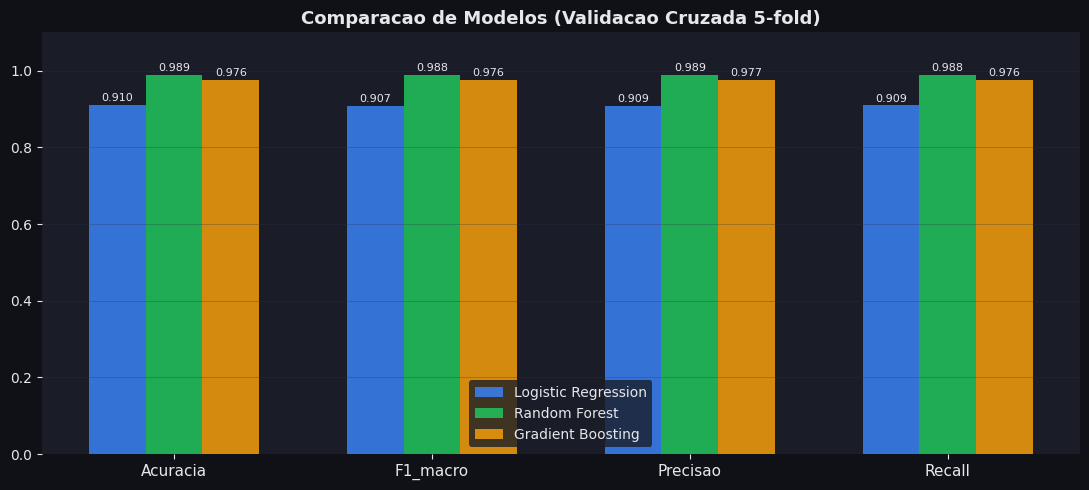

In [27]:
fig, ax = plt.subplots(figsize=(11, 5), facecolor=BG)

metricas = ['Acuracia', 'F1_macro', 'Precisao', 'Recall']
nomes    = list(df_resultados.index)
x        = np.arange(len(metricas))
w        = 0.22
cores    = ['#3B82F6', '#22C55E', '#F59E0B']

for i, (nome, cor) in enumerate(zip(nomes, cores)):
    vals = [df_resultados.loc[nome, m] for m in metricas]
    bars = ax.bar(x + i*w - w, vals, width=w, label=nome, color=cor, alpha=0.85, edgecolor='none')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, color=TEXT)

ax.set_xticks(x)
ax.set_xticklabels(metricas, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_title('Comparacao de Modelos (Validacao Cruzada 5-fold)', fontsize=13, fontweight='bold', color=TEXT)
ax.legend(facecolor=CARD, labelcolor=TEXT, edgecolor='none')
ax.grid(axis='y', alpha=0.4)
ax.spines[:].set_visible(False)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TC4_Obesity/viz7_comparacao_modelos.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

### Seleção e otimização do melhor modelo

O modelo com maior F1-Score macro é selecionado para otimização de hiperparâmetros via GridSearchCV. F1 macro é a métrica de referência por penalizar igualmente erros em todas as 7 classes.

In [28]:
melhor_nome = df_resultados['F1_macro'].idxmax()
print(f'Melhor modelo: {melhor_nome}')
print(f'F1 macro (CV): {df_resultados.loc[melhor_nome, "F1_macro"]:.4f}')

# Grid de hiperparâmetros por modelo
grids = {
    'Random Forest': {
        'modelo': RandomForestClassifier(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [200, 300],
            'max_depth'   : [None, 20, 30],
            'min_samples_split': [2, 5],
        }
    },
    'Gradient Boosting': {
        'modelo': GradientBoostingClassifier(random_state=42),
        'params': {
            'n_estimators' : [100, 200],
            'learning_rate': [0.05, 0.1],
            'max_depth'    : [3, 5],
        }
    },
    'Logistic Regression': {
        'modelo': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'C'      : [0.1, 1, 10],
            'solver' : ['lbfgs', 'saga'],
        }
    }
}

cfg = grids[melhor_nome]
grid_search = GridSearchCV(
    cfg['modelo'], cfg['params'],
    cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f'\nMelhores parametros: {grid_search.best_params_}')
print(f'F1 macro (GridSearch): {grid_search.best_score_:.4f}')

modelo_final = grid_search.best_estimator_

Melhor modelo: Random Forest
F1 macro (CV): 0.9884
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Melhores parametros: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
F1 macro (GridSearch): 0.9890


### Avaliação no conjunto de teste

Resultado do modelo otimizado aplicado ao conjunto de teste — dados que não participaram do treinamento nem da busca de hiperparâmetros.

In [29]:
y_pred = modelo_final.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='macro')

print(f'Acuracia no teste : {acc:.4f} ({acc*100:.2f}%)')
print(f'F1 macro no teste : {f1:.4f}')
print(f'Meta do projeto   : 75.00%')
print(f'Resultado         : {"APROVADO" if acc >= 0.75 else "ABAIXO DA META"}')

print('\nRelatorio de classificacao:')
print(classification_report(y_test, y_pred, target_names=TARGET_ORDER))

Acuracia no teste : 0.9811 (98.11%)
F1 macro no teste : 0.9806
Meta do projeto   : 75.00%
Resultado         : APROVADO

Relatorio de classificacao:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.98      0.99        54
      Normal_Weight       0.95      0.98      0.97        58
 Overweight_Level_I       0.95      0.97      0.96        58
Overweight_Level_II       1.00      0.97      0.98        58
     Obesity_Type_I       1.00      1.00      1.00        70
    Obesity_Type_II       0.98      0.98      0.98        60
   Obesity_Type_III       0.98      0.98      0.98        65

           accuracy                           0.98       423
          macro avg       0.98      0.98      0.98       423
       weighted avg       0.98      0.98      0.98       423



### Matriz de confusão

Visualização dos erros por classe. A diagonal principal representa predições corretas. Erros fora da diagonal indicam confusão entre classes adjacentes, esperado em classificação ordinal.

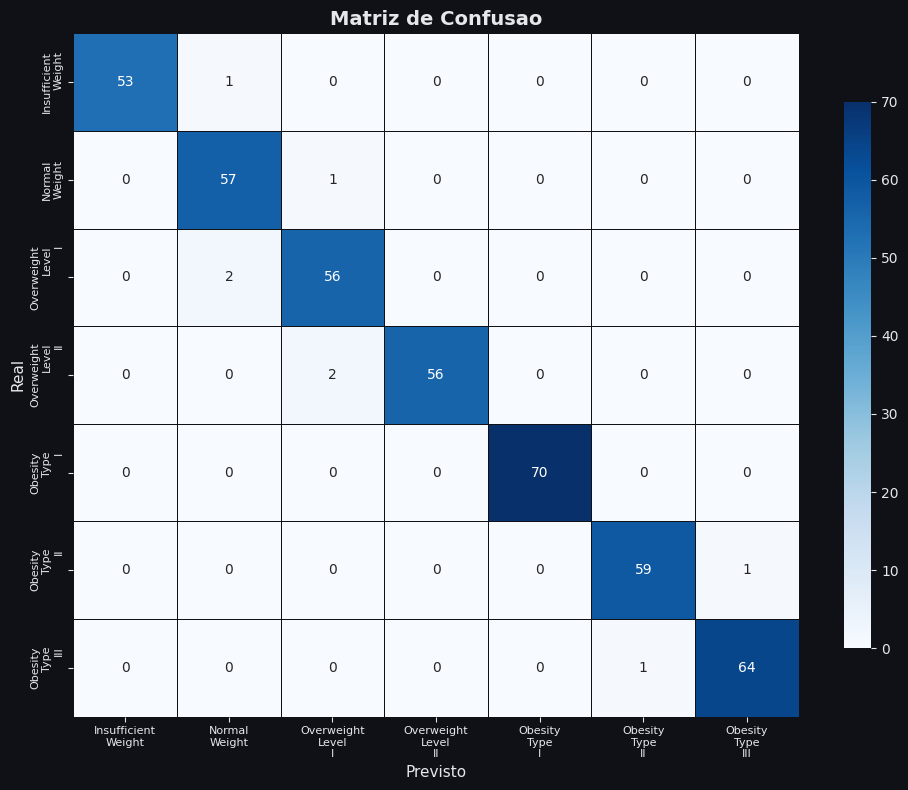

In [30]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8), facecolor=BG)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[t.replace('_', '\n') for t in TARGET_ORDER],
            yticklabels=[t.replace('_', '\n') for t in TARGET_ORDER],
            linewidths=0.5, linecolor=BG, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_xlabel('Previsto', fontsize=11)
ax.set_ylabel('Real', fontsize=11)
ax.set_title('Matriz de Confusao', fontsize=14, fontweight='bold', color=TEXT)
ax.tick_params(axis='both', labelsize=8)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TC4_Obesity/viz8_matriz_confusao.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

### Feature importance do modelo final

Variáveis ordenadas por importância no modelo selecionado. Confirma as hipóteses levantadas na análise exploratória.

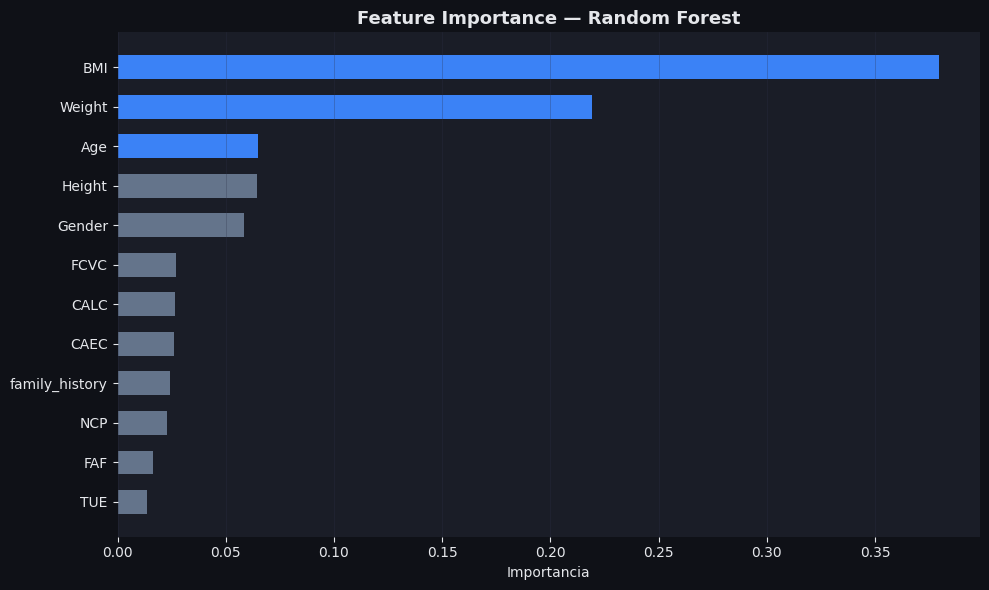

In [31]:
if hasattr(modelo_final, 'feature_importances_'):
    imp = pd.Series(modelo_final.feature_importances_, index=X_train.columns)
else:
    imp = pd.Series(abs(modelo_final.coef_).mean(axis=0), index=X_train.columns)

imp = imp.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
top = imp.head(12)
cores = ['#3B82F6' if i < 3 else '#64748B' for i in range(len(top))]
ax.barh(top.index[::-1], top.values[::-1], color=cores[::-1], edgecolor='none', height=0.6)
ax.set_title(f'Feature Importance — {melhor_nome}', fontsize=13, fontweight='bold', color=TEXT)
ax.set_xlabel('Importancia')
ax.grid(axis='x', alpha=0.4)
ax.spines[:].set_visible(False)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TC4_Obesity/viz9_feature_importance_final.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

### Exportação do modelo treinado

O modelo final é salvo em formato `.pkl` junto com os metadados necessários para reconstruir o pipeline de predição no Streamlit.

In [32]:
import pickle, json

# Salva o modelo
with open('/content/drive/MyDrive/TC4_Obesity/modelo_final.pkl', 'wb') as f:
    pickle.dump(modelo_final, f)

# Atualiza metadados com informações do modelo
with open('/content/drive/MyDrive/TC4_Obesity/feature_metadata.json') as f:
    meta = json.load(f)

meta['modelo_nome']    = melhor_nome
meta['acuracia_teste'] = round(float(acc), 4)
meta['f1_macro_teste'] = round(float(f1), 4)
meta['best_params']    = grid_search.best_params_

with open('/content/drive/MyDrive/TC4_Obesity/feature_metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

print(f'Modelo salvo: modelo_final.pkl')
print(f'Algoritmo   : {melhor_nome}')
print(f'Acuracia    : {acc*100:.2f}%')
print(f'F1 macro    : {f1*100:.2f}%')
print('\nArquivos prontos para o Streamlit:')
print('  modelo_final.pkl')
print('  feature_metadata.json')
print('  scaler.pkl')

Modelo salvo: modelo_final.pkl
Algoritmo   : Random Forest
Acuracia    : 98.11%
F1 macro    : 98.06%

Arquivos prontos para o Streamlit:
  modelo_final.pkl
  feature_metadata.json
  scaler.pkl


---
*Fase 4: Aplicação preditiva com Streamlit*